# Optimized Heart Failure Outcome Prediction

This notebook trains a machine learning model to predict:

`DEATH_EVENT`

The notebook will:

1. Load the dataset
2. Check missing values and duplicates
3. Remove duplicate rows
4. Train two model versions:
   - `clinical_safe_no_time`
   - `with_time`
5. Fine-tune multiple models
6. Tune the prediction threshold
7. Save the best model
8. Predict a new patient

Important: the `time` column is follow-up duration. It can improve score, but may not be available at the first clinical visit.

### Run this only once if libraries are missing


In [3]:
!pip install pandas numpy scikit-learn scipy joblib matplotlib

In [4]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import randint, loguniform

from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

## Configuration

In [5]:
RANDOM_STATE = 42
TARGET = "DEATH_EVENT"

DATA_PATH = Path("heart_failure_clinical_records.csv")

OUTPUT_DIR = Path("outputs")
MODEL_DIR = Path("models")

OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# Increase this for stronger tuning.
# Use 10 for quick testing, 25 for good default, 50+ for deeper tuning.
N_ITER_PER_MODEL = 25

CV_SPLITS = 5

# Average precision means PR-AUC.
# This is useful for medical prediction because the positive class can be imbalanced.
SCORING = "average_precision"

print("Using dataset:", DATA_PATH)

Using dataset: heart_failure_clinical_records.csv


## Load dataset

In [6]:
df_raw = pd.read_csv(DATA_PATH)

print("Raw dataset shape:", df_raw.shape)

display(df_raw.head())

print("\nColumns:")
print(df_raw.columns.tolist())

Raw dataset shape: (5000, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.0,0,748,0,45,0,263358.03,1.3,137,1,1,88,0
1,65.0,0,56,0,25,0,305000.00,5.0,130,1,0,207,0
2,45.0,0,582,1,38,0,319000.00,0.9,140,0,0,244,0
3,60.0,1,754,1,40,1,328000.00,1.2,126,1,0,90,0
4,95.0,1,582,0,30,0,461000.00,2.0,132,1,0,50,1



Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']


### Check missing values, duplicates, and target balance

In [7]:
print("Missing values:")
display(df_raw.isna().sum())

print("\nDuplicate rows:")
print(df_raw.duplicated().sum())

print("\nTarget distribution:")
display(df_raw[TARGET].value_counts())

print("\nTarget distribution ratio:")
display(df_raw[TARGET].value_counts(normalize=True).rename("ratio"))

Missing values:


age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


Duplicate rows:
3680

Target distribution:


DEATH_EVENT
0    3432
1    1568
Name: count, dtype: int64


Target distribution ratio:


DEATH_EVENT
0    0.6864
1    0.3136
Name: ratio, dtype: float64

### Remove duplicate rows

In [9]:
df = df_raw.drop_duplicates().reset_index(drop=True)

print("Shape before duplicate removal:", df_raw.shape)
print("Shape after duplicate removal:", df.shape)
print("Removed rows:", len(df_raw) - len(df))

print("\nTarget distribution after cleaning:")
display(df[TARGET].value_counts())

print("\nTarget ratio after cleaning:")
display(df[TARGET].value_counts(normalize=True).rename("ratio"))

Shape before duplicate removal: (5000, 13)
Shape after duplicate removal: (1320, 13)
Removed rows: 3680

Target distribution after cleaning:


DEATH_EVENT
0    923
1    397
Name: count, dtype: int64


Target ratio after cleaning:


DEATH_EVENT
0    0.699242
1    0.300758
Name: ratio, dtype: float64

## Why remove duplicates?

If duplicate rows exist, the same patient record may appear in both training and test data.

That makes the model look better than it really is.

So we remove exact duplicate rows before splitting the data.

### Helper functions

In [10]:
def get_probability(model, X: pd.DataFrame) -> np.ndarray:
    """
    Returns probability for class 1.
    In this dataset, class 1 means DEATH_EVENT = 1.
    """
    return model.predict_proba(X)[:, 1]


def find_best_threshold(y_true, probabilities, metric="f1"):
    """
    Instead of using default threshold 0.50,
    this function tests thresholds from 0.05 to 0.95
    and selects the best one.
    """

    rows = []

    for threshold in np.linspace(0.05, 0.95, 181):
        predictions = (probabilities >= threshold).astype(int)

        rows.append(
            {
                "threshold": float(threshold),
                "f1": f1_score(y_true, predictions, zero_division=0),
                "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
                "precision": precision_score(y_true, predictions, zero_division=0),
                "recall": recall_score(y_true, predictions, zero_division=0),
            }
        )

    threshold_table = pd.DataFrame(rows)

    threshold_table = threshold_table.sort_values(
        [metric, "balanced_accuracy", "recall"],
        ascending=False,
    ).reset_index(drop=True)

    best_threshold = float(threshold_table.loc[0, "threshold"])

    return best_threshold, threshold_table


def evaluate_model(model, X_test, y_test, threshold):
    """
    Evaluates model using tuned threshold.
    """

    probabilities = get_probability(model, X_test)
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

    metrics = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_test, predictions)),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, predictions)),
        "precision": float(precision_score(y_test, predictions, zero_division=0)),
        "recall": float(recall_score(y_test, predictions, zero_division=0)),
        "f1": float(f1_score(y_test, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_test, probabilities)),
        "pr_auc_average_precision": float(average_precision_score(y_test, probabilities)),
        "confusion_matrix": {
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        },
        "classification_report": classification_report(
            y_test,
            predictions,
            zero_division=0,
        ),
    }

    return metrics, predictions, probabilities
    

## Why tune the threshold?

Many models use `0.50` as the default decision threshold.

Example:

- Probability = 0.70 → predict 1
- Probability = 0.30 → predict 0

But in medical prediction, `0.50` is not always the best value.

This notebook finds a better threshold using F1-score.

In [11]:
def build_model_search_spaces():
    """
    Defines models and their hyperparameter search spaces.
    """

    return {
        "logistic_regression": {
            "pipeline": Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", RobustScaler()),
                    (
                        "model",
                        LogisticRegression(
                            max_iter=5000,
                            random_state=RANDOM_STATE,
                        ),
                    ),
                ]
            ),
            "params": {
                "model__C": loguniform(0.005, 20),
                "model__penalty": ["l1", "l2"],
                "model__solver": ["liblinear"],
                "model__class_weight": [None, "balanced"],
            },
        },

        "svm_rbf": {
            "pipeline": Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", RobustScaler()),
                    (
                        "model",
                        SVC(
                            probability=True,
                            random_state=RANDOM_STATE,
                        ),
                    ),
                ]
            ),
            "params": {
                "model__C": loguniform(0.05, 50),
                "model__gamma": loguniform(0.0005, 0.5),
                "model__class_weight": [None, "balanced"],
            },
        },

        "random_forest": {
            "pipeline": Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "model",
                        RandomForestClassifier(
                            random_state=RANDOM_STATE,
                            n_jobs=-1,
                        ),
                    ),
                ]
            ),
            "params": {
                "model__n_estimators": randint(250, 800),
                "model__max_depth": [None, 3, 4, 5, 6, 8, 10, 14],
                "model__min_samples_split": randint(2, 30),
                "model__min_samples_leaf": randint(1, 20),
                "model__max_features": ["sqrt", "log2", None],
                "model__bootstrap": [True, False],
                "model__class_weight": [None, "balanced", "balanced_subsample"],
            },
        },

        "extra_trees": {
            "pipeline": Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "model",
                        ExtraTreesClassifier(
                            random_state=RANDOM_STATE,
                            n_jobs=-1,
                        ),
                    ),
                ]
            ),
            "params": {
                "model__n_estimators": randint(250, 800),
                "model__max_depth": [None, 3, 4, 5, 6, 8, 10, 14],
                "model__min_samples_split": randint(2, 30),
                "model__min_samples_leaf": randint(1, 20),
                "model__max_features": ["sqrt", "log2", None],
                "model__bootstrap": [True, False],
                "model__class_weight": [None, "balanced"],
            },
        },

        "hist_gradient_boosting": {
            "pipeline": Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "model",
                        HistGradientBoostingClassifier(
                            random_state=RANDOM_STATE,
                            early_stopping=True,
                        ),
                    ),
                ]
            ),
            "params": {
                "model__learning_rate": loguniform(0.01, 0.25),
                "model__max_iter": randint(80, 400),
                "model__max_leaf_nodes": randint(4, 40),
                "model__min_samples_leaf": randint(5, 60),
                "model__l2_regularization": loguniform(1e-4, 5.0),
                "model__class_weight": [None, "balanced"],
            },
        },
    }

## Models used

This notebook tests multiple models:

1. Logistic Regression  
   Simple, stable, and interpretable.

2. SVM RBF  
   Good for smaller nonlinear datasets.

3. Random Forest  
   Strong tree-based ensemble.

4. Extra Trees  
   Similar to Random Forest, often strong on tabular data.

5. HistGradientBoosting  
   Fast gradient boosting model.

The best model is selected automatically using cross-validation PR-AUC.

In [12]:
def train_one_variant(df, variant_name, use_time):
    """
    Trains one version of the dataset.

    use_time = False means the time column is removed.
    use_time = True means the time column is included.
    """

    feature_columns = [col for col in df.columns if col != TARGET]

    if not use_time and "time" in feature_columns:
        feature_columns.remove("time")

    X = df[feature_columns]
    y = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    cv = StratifiedKFold(
        n_splits=CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    leaderboard_rows = []
    searches = {}

    search_spaces = build_model_search_spaces()

    for model_name, spec in search_spaces.items():
        print(f"\nTraining variant: {variant_name}")
        print(f"Model: {model_name}")

        search = RandomizedSearchCV(
            estimator=spec["pipeline"],
            param_distributions=spec["params"],
            n_iter=N_ITER_PER_MODEL,
            scoring=SCORING,
            cv=cv,
            n_jobs=-1,
            verbose=1,
            random_state=RANDOM_STATE,
            refit=True,
        )

        search.fit(X_train, y_train)

        leaderboard_rows.append(
            {
                "variant": variant_name,
                "model": model_name,
                "cv_best_score_pr_auc": float(search.best_score_),
                "best_params": search.best_params_,
            }
        )

        searches[model_name] = search

    leaderboard = pd.DataFrame(leaderboard_rows)
    leaderboard = leaderboard.sort_values(
        "cv_best_score_pr_auc",
        ascending=False,
    )

    print("\nLeaderboard:")
    display(leaderboard)

    leaderboard.to_csv(
        OUTPUT_DIR / f"leaderboard_{variant_name}.csv",
        index=False,
    )

    best_model_name = leaderboard.iloc[0]["model"]
    best_estimator = searches[best_model_name].best_estimator_

    print(f"\nBest model for {variant_name}: {best_model_name}")

    oof_probabilities = cross_val_predict(
        best_estimator,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    best_threshold, threshold_table = find_best_threshold(
        y_train,
        oof_probabilities,
        metric="f1",
    )

    threshold_table.to_csv(
        OUTPUT_DIR / f"threshold_search_{variant_name}.csv",
        index=False,
    )

    print("\nBest threshold:", best_threshold)
    display(threshold_table.head(10))

    best_estimator.fit(X_train, y_train)

    metrics, predictions, probabilities = evaluate_model(
        best_estimator,
        X_test,
        y_test,
        best_threshold,
    )

    print("\nTest metrics:")
    print(
        json.dumps(
            {key: value for key, value in metrics.items() if key != "classification_report"},
            indent=2,
        )
    )

    print("\nClassification report:")
    print(metrics["classification_report"])

    ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    plt.title(f"Confusion Matrix — {variant_name}")
    plt.show()

    result = {
        "variant": variant_name,
        "use_time": use_time,
        "feature_columns": feature_columns,
        "best_model_name": best_model_name,
        "best_cv_pr_auc": float(leaderboard.iloc[0]["cv_best_score_pr_auc"]),
        "test_metrics": metrics,
        "train_rows": int(len(X_train)),
        "test_rows": int(len(X_test)),
    }

    model_package = {
        "model": best_estimator,
        "threshold": best_threshold,
        "feature_columns": feature_columns,
        "target": TARGET,
        "variant": variant_name,
        "metrics": result,
    }

    model_path = MODEL_DIR / f"heart_failure_{variant_name}.joblib"

    joblib.dump(model_package, model_path)

    with open(OUTPUT_DIR / f"metrics_{variant_name}.json", "w", encoding="utf-8") as file:
        json.dump(result, file, indent=2)

    print("\nSaved model to:", model_path)

    return result

Train model without time


Training variant: clinical_safe_no_time
Model: logistic_regression
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Training variant: clinical_safe_no_time
Model: svm_rbf
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Training variant: clinical_safe_no_time
Model: random_forest
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Training variant: clinical_safe_no_time
Model: extra_trees
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Training variant: clinical_safe_no_time
Model: hist_gradient_boosting
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Leaderboard:


,variant,model,cv_best_score_pr_auc,best_params
4,clinical_safe_no_time,hist_gradient_boosting,0.916319,"{'model__class_weight': None, 'model__l2_regul..."
2,clinical_safe_no_time,random_forest,0.916253,"{'model__bootstrap': False, 'model__class_weig..."
3,clinical_safe_no_time,extra_trees,0.853233,"{'model__bootstrap': True, 'model__class_weigh..."
1,clinical_safe_no_time,svm_rbf,0.762409,"{'model__C': 0.0547980226846292, 'model__class..."
0,clinical_safe_no_time,logistic_regression,0.617057,"{'model__C': 2.165988248422518, 'model__class_..."



Best model for clinical_safe_no_time: hist_gradient_boosting

Best threshold: 0.43499999999999994


,threshold,f1,balanced_accuracy,precision,recall
0,0.435,0.865385,0.900138,0.882353,0.849057
1,0.440,0.863563,0.898566,0.881967,0.845912
2,0.475,0.863192,0.895664,0.895270,0.833333
3,0.445,0.863124,0.897671,0.884488,0.842767
4,0.450,0.862682,0.896776,0.887043,0.839623
5,0.455,0.862237,0.895881,0.889632,0.836478
6,0.410,0.862124,0.899895,0.869010,0.855346
7,0.400,0.862069,0.901902,0.859375,0.864780
8,0.495,0.861842,0.892979,0.903448,0.823899
9,0.465,0.861789,0.894986,0.892256,0.833333



Test metrics:
{
  "threshold": 0.43499999999999994,
  "accuracy": 0.9356060606060606,
  "balanced_accuracy": 0.9141635306192268,
  "precision": 0.918918918918919,
  "recall": 0.8607594936708861,
  "f1": 0.8888888888888888,
  "roc_auc": 0.9761888470749229,
  "pr_auc_average_precision": 0.9578489150622663,
  "confusion_matrix": {
    "tn": 179,
    "fp": 6,
    "fn": 11,
    "tp": 68
  }
}

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       185
           1       0.92      0.86      0.89        79

    accuracy                           0.94       264
   macro avg       0.93      0.91      0.92       264
weighted avg       0.94      0.94      0.93       264



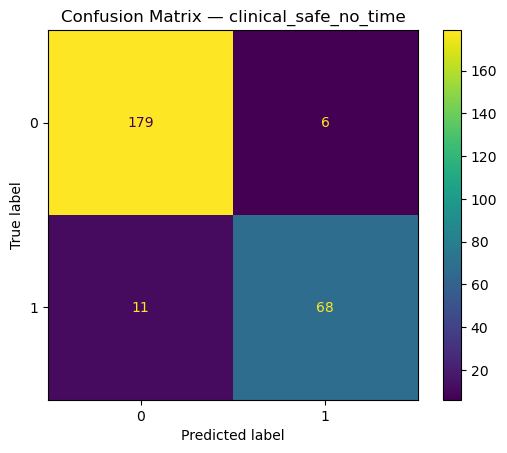


Saved model to: models\heart_failure_clinical_safe_no_time.joblib


In [13]:
no_time_result = train_one_variant(
    df=df,
    variant_name="clinical_safe_no_time",
    use_time=False,
)

with time


Training variant: with_time
Model: logistic_regression
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Training variant: with_time
Model: svm_rbf
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Training variant: with_time
Model: random_forest
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Training variant: with_time
Model: extra_trees
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Training variant: with_time
Model: hist_gradient_boosting
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Leaderboard:


,variant,model,cv_best_score_pr_auc,best_params
2,with_time,random_forest,0.960559,"{'model__bootstrap': False, 'model__class_weig..."
4,with_time,hist_gradient_boosting,0.954318,"{'model__class_weight': None, 'model__l2_regul..."
3,with_time,extra_trees,0.924383,"{'model__bootstrap': True, 'model__class_weigh..."
1,with_time,svm_rbf,0.846117,"{'model__C': 29.146922714973684, 'model__class..."
0,with_time,logistic_regression,0.795311,"{'model__C': 0.17982988826617075, 'model__clas..."



Best model for with_time: random_forest

Best threshold: 0.575


,threshold,f1,balanced_accuracy,precision,recall
0,0.575,0.898361,0.918622,0.938356,0.861635
1,0.580,0.896552,0.917050,0.938144,0.858491
2,0.560,0.895765,0.918162,0.929054,0.864780
3,0.565,0.895765,0.918162,0.929054,0.864780
4,0.585,0.894737,0.915478,0.937931,0.855346
5,0.590,0.894737,0.915478,0.937931,0.855346
6,0.595,0.894389,0.914583,0.940972,0.852201
7,0.555,0.894309,0.917485,0.925926,0.864780
8,0.525,0.894231,0.920387,0.911765,0.877358
9,0.570,0.893964,0.916590,0.928814,0.861635



Test metrics:
{
  "threshold": 0.575,
  "accuracy": 0.946969696969697,
  "balanced_accuracy": 0.922271638727335,
  "precision": 0.9577464788732394,
  "recall": 0.8607594936708861,
  "f1": 0.9066666666666666,
  "roc_auc": 0.9877523092712966,
  "pr_auc_average_precision": 0.9733362901536461,
  "confusion_matrix": {
    "tn": 182,
    "fp": 3,
    "fn": 11,
    "tp": 68
  }
}

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       185
           1       0.96      0.86      0.91        79

    accuracy                           0.95       264
   macro avg       0.95      0.92      0.93       264
weighted avg       0.95      0.95      0.95       264



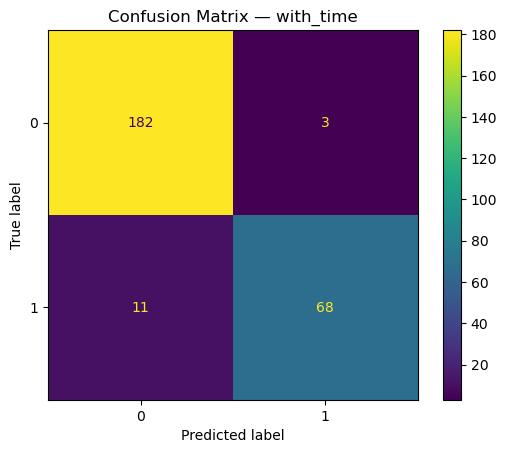


Saved model to: models\heart_failure_with_time.joblib


In [14]:
with_time_result = train_one_variant(
    df=df,
    variant_name="with_time",
    
    use_time=True,
)

## Which model should you use?

There are two trained models:

### 1. `clinical_safe_no_time`

This model does not use the `time` column.

Use this if you want to predict the outcome at the first clinical visit.

### 2. `with_time`

This model uses the `time` column.

It may get a better score, but the `time` column is follow-up duration, so it may not be available for a new patient at the start.

In [15]:
all_results = {
    "clinical_safe_no_time": no_time_result,
    "with_time": with_time_result,
}

ranking = sorted(
    all_results.values(),
    key=lambda result: result["test_metrics"]["pr_auc_average_precision"],
    reverse=True,
)

best_overall = ranking[0]
best_variant = best_overall["variant"]

print("Best overall variant:", best_variant)
print("Best model:", best_overall["best_model_name"])
print("Test PR-AUC:", best_overall["test_metrics"]["pr_auc_average_precision"])
print("Test F1:", best_overall["test_metrics"]["f1"])
print("Test Recall:", best_overall["test_metrics"]["recall"])
print("Test Precision:", best_overall["test_metrics"]["precision"])

best_model_path = MODEL_DIR / f"heart_failure_{best_variant}.joblib"
overall_path = MODEL_DIR / "best_model_overall.joblib"

package = joblib.load(best_model_path)
package["overall_selection_note"] = "Selected by highest test PR-AUC among trained variants."

joblib.dump(package, overall_path)

with open(OUTPUT_DIR / "all_results.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "clinical_safe_no_time": no_time_result,
            "with_time": with_time_result,
            "best_overall_variant": best_variant,
            "best_overall_model_file": str(overall_path),
        },
        file,
        indent=2,
    )

print("\nSaved final selected model to:", overall_path)

Best overall variant: with_time
Best model: random_forest
Test PR-AUC: 0.9733362901536461
Test F1: 0.9066666666666666
Test Recall: 0.8607594936708861
Test Precision: 0.9577464788732394

Saved final selected model to: models\best_model_overall.joblib


In [16]:
sample_patient = {
    "age": 65,
    "anaemia": 0,
    "creatinine_phosphokinase": 582,
    "diabetes": 0,
    "ejection_fraction": 38,
    "high_blood_pressure": 1,
    "platelets": 263358.03,
    "serum_creatinine": 1.1,
    "serum_sodium": 137,
    "sex": 1,
    "smoking": 0,
    "time": 120,
}

package = joblib.load(MODEL_DIR / "best_model_overall.joblib")

model = package["model"]
threshold = package["threshold"]
feature_columns = package["feature_columns"]

X_new = pd.DataFrame([sample_patient])[feature_columns]

probability = model.predict_proba(X_new)[:, 1][0]
prediction = int(probability >= threshold)

print("Probability of DEATH_EVENT = 1:", round(probability, 4))
print("Threshold:", round(threshold, 4))
print("Prediction:", prediction)

if prediction == 1:
    print("Model prediction: Higher risk")
else:
    print("Model prediction: Lower risk")

Probability of DEATH_EVENT = 1: 0.0611
Threshold: 0.575
Prediction: 0
Model prediction: Lower risk


In [21]:
NEW_PATIENTS_PATH = Path("new_patients.csv")

# Load trained model first (we need feature columns)
package = joblib.load(MODEL_DIR / "best_model_overall.joblib")

model = package["model"]
threshold = package["threshold"]
feature_columns = package["feature_columns"]

# ---------------------------------------
# 1. Create CSV if it doesn't exist or empty
# ---------------------------------------
if (not NEW_PATIENTS_PATH.exists()) or NEW_PATIENTS_PATH.stat().st_size == 0:
    print("Creating new_patients.csv automatically...")

    np.random.seed(42)
    n_samples = 100

    new_patients = pd.DataFrame({
        "age": np.random.randint(40, 90, n_samples),
        "anaemia": np.random.randint(0, 2, n_samples),
        "creatinine_phosphokinase": np.random.randint(50, 800, n_samples),
        "diabetes": np.random.randint(0, 2, n_samples),
        "ejection_fraction": np.random.randint(20, 60, n_samples),
        "high_blood_pressure": np.random.randint(0, 2, n_samples),
        "platelets": np.random.uniform(150000, 400000, n_samples),
        "serum_creatinine": np.random.uniform(0.5, 2.5, n_samples),
        "serum_sodium": np.random.randint(120, 150, n_samples),
        "sex": np.random.randint(0, 2, n_samples),
        "smoking": np.random.randint(0, 2, n_samples),
        "time": np.random.randint(1, 300, n_samples),
    })

    # Save the newly created CSV
    new_patients.to_csv(NEW_PATIENTS_PATH, index=False)
    print("new_patients.csv created.")

else:
    print("Using existing new_patients.csv")
    new_patients = pd.read_csv(NEW_PATIENTS_PATH)

# ---------------------------------------
# 2. Predict
# ---------------------------------------
X_new = new_patients[feature_columns]

probabilities = model.predict_proba(X_new)[:, 1]
predictions = (probabilities >= threshold).astype(int)

new_patients["death_event_probability"] = probabilities
new_patients["death_event_prediction"] = predictions

# ---------------------------------------
# 3. Save output
# ---------------------------------------
output_file = "predictions_output.csv"
new_patients.to_csv(output_file, index=False)

# ---------------------------------------
# 4. Display
# ---------------------------------------
display(new_patients.head())

print("\nSaved predictions to predictions_output.csv")
print(f"Total rows: {len(new_patients)}")

Creating new_patients.csv automatically...
new_patients.csv created.


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event_probability,death_event_prediction
0,78,0,689,1,23,0,353617.120647,2.438605,129,0,1,165,0.552647,0
1,68,1,555,0,54,0,220463.693693,1.546196,136,0,0,5,0.878626,1
2,54,0,397,1,36,1,179541.206905,1.758797,147,0,1,78,0.300858,0
3,82,1,522,1,47,1,324184.291341,1.891497,139,1,1,62,0.894396,1
4,47,1,280,0,49,1,307235.711695,1.409082,143,0,1,132,0.091585,0



Saved predictions to predictions_output.csv
Total rows: 100


## Metrics explanation

### Accuracy
Overall percentage of correct predictions.

### Precision
When the model predicts `DEATH_EVENT = 1`, precision tells how often it is correct.

### Recall
Out of all real death events, recall tells how many the model catches.

### F1-score
Balance between precision and recall.

### ROC-AUC
Shows how well the model separates class 0 and class 1 across thresholds.

### PR-AUC / Average Precision
Very useful for imbalanced datasets. This notebook selects the best model using PR-AUC.

### Confusion Matrix

- TN = Correctly predicted no death event
- FP = Predicted death event, but actual was no death event
- FN = Predicted no death event, but actual was death event
- TP = Correctly predicted death event